Cauã Benini da Silva (RA )

Universidade Federal de São Carlos (UFSCar)

# Trabalho de Conclusão de Curso (TCC) - Aplicação dos Modelos


# Introdução

O objetivo deste trabalho é prever casos de hipotensão intradiálica em pacientes renais crônicos e posteriormente, adaptar estes modelos para um dashboard interativo a fim de simular sessões de hemodiálise e, com base em atributos demográficos e clínicos, prever se haverá ou não hipotensão durante a sessão.

Este trabalho se baseou no artigo *Predicting the Appearance of Hypotension during Hemodialysis Sessions Using Machine Learning Classifiers* (https://www.mdpi.com/1660-4601/18/5/2364#Abstract).

Abaixo, segue a importação das bibliotecas necessárias para esse desenvolvimento.

In [1]:
# Realizar download do Dataset do Drive
!pip install gdown pandas scikit-learn matplotlib xgboost


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Transformar em Dataframe do Pandas e printar
import pandas as pd

df_flat = pd.read_csv('data\dataset_flat_V2.csv', sep=";", index_col=False)
df_flat

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\cauab\AppData\Local\Temp\ipykernel_14148\3721516749.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_flat = pd.read_csv('data\dataset_flat_V2.csv', sep=";", index_col=False)


,SEX,AGE,DIA,WDR_H0,WDR_H1,WDR_H2,WDR_H3,WDR_H4,WDR_H5,WPR_H0,...,BAT_GROUP_Grupo 2 - EuCliD_H3,BAT_GROUP_Grupo 2 - EuCliD_H4,BAT_GROUP_Grupo 2 - EuCliD_H5,BAT_GROUP_Grupo 3 - Demais classes_H0,BAT_GROUP_Grupo 3 - Demais classes_H1,BAT_GROUP_Grupo 3 - Demais classes_H2,BAT_GROUP_Grupo 3 - Demais classes_H3,BAT_GROUP_Grupo 3 - Demais classes_H4,BAT_GROUP_Grupo 3 - Demais classes_H5,Target
0,0,32.0,8,64.0,64.0,64.0,64.0,64.0,64.0,66.268557,...,0,0,0,0,0,0,0,0,0,0
1,0,33.0,1,46.0,45.5,45.5,48.0,58.0,59.8,48.800000,...,1,1,1,0,0,0,0,0,0,1
2,0,33.0,1,59.5,59.5,59.5,59.5,60.0,60.0,63.700000,...,1,1,1,0,0,0,0,0,0,0
3,0,33.0,1,63.0,63.0,62.4,61.4,61.4,61.4,64.300000,...,1,1,1,0,0,0,0,0,0,1
4,0,33.0,1,61.4,61.0,60.7,60.4,60.4,60.4,64.200000,...,1,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15747,1,97.0,1,43.5,43.5,43.5,43.5,43.5,43.0,44.100000,...,0,0,0,1,1,1,1,1,1,0
15748,1,97.0,1,42.0,42.0,42.0,42.0,42.0,43.0,43.200000,...,0,0,0,1,1,1,1,1,1,1
15749,1,97.0,1,43.0,43.0,43.0,43.0,43.0,43.0,42.200000,...,0,0,0,1,1,1,1,1,1,1
15750,1,97.0,1,43.0,43.0,43.0,43.0,43.0,43.0,44.400000,...,0,0,0,1,1,1,1,1,1,0


# Aplicação dos Modelos - Predição de Target


## 1. Amostragem

O código abaixo ilustra a amostragem realizada para se ter um conjunto de treino e validação dos modelos. Nela, algumas escolhas foram feitas, considerando a natureza do dataset:

* **Amostragem holdout:** considerando que após todas operações de pré-processamento necessária restaram-se 13895 tuplas de dados no dataset, pode-se afirmar que existe uma quantidade de dados suficiente para que um bom treinamento e um bom conjunto de testes seja dividido para que se faça a validação dos dados contra overfit e má generalização. Além disso, o uso de cross-validation com tamanho dataset seria custoso, o que se evidenciaria com mais força com o posterior uso de técnicas de GridSearch para refino dos hiperparâmetros e aplicação de diferentes modelos. Assim, um holdout clássico simples com 80% dos dados para treino e 20% dos dados para validação foram usados.

* **Amostragem estratificada:** Outra escolha feita foi a estratificação dos dados com base na coluna y (*Target*). Isso foi feito considerando que existe um desequilíbrio entre a quantidade de tuplas pertencentes a cada uma das classes, sendo que os alvos com hipotensão intradiálica (*Target = 1*) representam 9194 objetos e aqueles sem hipotensão intradiálica ((*Target = 0*) são 4701. Dessa forma, a estratificação por tal coluna garante uma representação proporcional dos dados nos conjuntos de treino e teste, mantendo a essência da população e evitando viés.

In [3]:
from sklearn.model_selection import train_test_split

y = df_flat['Target']
X = df_flat.drop(columns=['Target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

## 2. Metrificação de Desempenho

Antes da aplicação dos modelos, foi definida uma função para utilização padronizada das métricas de desempenho. Nele, foi decidido por usar 3 medidas:
* **Acurácia**: por oferecer uma perspectiva geral da performance do modelo, indicando a proporção de previsões corretas.
* **Precisão**: avaliação da confiabilidade das previsões positivas, cruvial quandos os custos de um falso positivo são altos (tal qual em casos clínicos).
* **F1-score**: combinação das métricas *Precisão* e *Recall*(proporção de positivos reais identificados corretamente) em uma única métrica, fornecendo um equilíbrio entre ambos.
* **AUC Score**: representa a área sob a curva ROC (Receiver Operating Characteristic), que avalia a capacidade do modelo em distinguir entre classes positivas e negativas em diferentes limiares de decisão. Um valor próximo de 1 indica excelente poder discriminativo, enquanto valores próximos de 0,5 sugerem desempenho equivalente ao acaso. Essa métrica é especialmente útil em cenários com classes desbalanceadas, pois fornece uma visão mais robusta da performance do modelo além das métricas tradicionais.

Além disso, foi exibida a matriz de confusão e a própria curva ROC para posteriores análise visuais e intuitivas do resultado.

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score
)

def evaluate(y_test, y_pred, y_scores, model_name):
    """
    Avalia um classificador binário.

    Parâmetros
    ----------
    y_test : array-like
        Rótulos verdadeiros (0/1).
    y_pred : array-like
        Previsões binárias (0/1).
    y_scores : array-like
        Scores contínuos por amostra (ex.: saída de decision_function ou
        probabilidades da classe positiva).
    model_name : str
        Nome do modelo (para títulos dos gráficos).

    Retorna
    -------
    tuple
        (accuracy, precision, f1_score, auc_score)
    """

    # Métricas de classificação
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1_sc = f1_score(y_test, y_pred)

    print(f'Classification Report for model {model_name}:\n\n', classification_report(y_test, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(cm)
    cm_display.plot()
    plt.title(f'Confusion Matrix for model {model_name}')
    plt.show()

    print("----------------------------------------------------")

    # Curva ROC e AUC usando y_scores (pode ser decision_function ou probabilidades)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')  # linha diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for model {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    return (acc, prec, f1_sc, auc_score)


In [5]:
# DF pra armazenar a acurácia de todos os modelos e depois comparar
result=pd.DataFrame(columns=['Model',
                             'Accuracy Score',
                             'Precision Score',
                             'F1-Score',
                             'AUC Score'] )

## 3. Algoritmos de Predição

Tendo em vista que utilizaremos múltiplos algoritmos de predição, há alguns cuidados específicos que podemos ter para obter melhores resultados.

#### Normalização
* **StandardScaler**: Utilizado para centralizar os dados em torno da média zero e desvio padrão igual a um. É indicado para algoritmos que assumem distribuição normal ou que são sensíveis à variância, como regressão logística, SVM e PCA. Essa normalização ajuda a evitar que variáveis com escalas diferentes dominem o processo de aprendizado.

* **MinMaxScaler**: Transforma os dados para um intervalo fixo, nesse caso, entre 0 e 1. É útil em algoritmos baseados em distância (como KNN) ou em redes neurais, onde valores em faixas controladas facilitam a convergência do treinamento. Preserva a distribuição original dos dados, mas garante que todos os atributos estejam na mesma escala.

#### Otimização de hiperparâmetros
* **GridSearchCV**: Outro fator a se considerar foi que a utilização do GridSearchCV, o qual testa exaustivamente diferentes modelos usando diferentes hiperparâmetros, utiliza internamente para comparação dos modelos a Cross-Validation com r folds definidos, de forma a retornar com mais confiabilidade um modelo bom, sem overfittings.

* **RandomizedSearchCV**: técnica de otimização de hiperparâmetros que busca aleatoriamente combinações de hiperparâmetros e avalia cada combinação usando validação cruzada. Ela é principalmente útil quando o espaço de busca é grande e a busca exaustiva (como GridSearchCV) é computacionalmente custosa.

#### Pipeline

O Pipeline do scikit-learn permite encadear etapas de pré-processamento e modelagem em uma única estrutura. Isso garante que todas as transformações (como normalização, seleção de atributos ou redução de dimensionalidade) sejam aplicadas de forma consistente tanto nos dados de treino quanto nos de teste, inclusive facilitanto a codificação.

Além disso, quando combinado com técnicas de otimização de hiperparâmetros (como GridSearchCV ou RandomizedSearchCV), o Pipeline assegura que cada conjunto de dados dentro da validação cruzada passe pelas mesmas etapas de pré-processamento, evitando *data leakage* e aumentando a confiabilidade dos resultados.

#### Salvar modelos para utilização offline

Para posterior utilização dos modelos treinados no dashboard, pode-se armazena-los em arquivos *.pkl*, por meio da biblioteca Joblib. Isso permite carregar o modelo já treinado sem necessidade de reprocessar todo o pipeline, economizando tempo e recursos computacionais.

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.pipeline import Pipeline 

from joblib import dump, load

### 3.1 SVM (*Support Vector Machine)*:



O SVM foi utilizado como base de comparação para os demais método aplicados, tendo em vista que junto ao algortimo de Árvores de Decisão (Decision Tree) - apresentado posteriormente - foram os aplicados pelo autor em um dos artigos base.

Esse algoritmo busca separar as classes por meio de um hiperplano ótimo, maximizando a margem entre elas. Quando os dados não são linearmente separáveis, utiliza funções de kernel para projetá-los em espaços de maior dimensão, permitindo a classificação adequada. É reconhecido por sua robustez em cenários de alta dimensionalidade e por apresentar bom desempenho mesmo em datasets desbalanceados, especialmente quando associado a técnicas de normalização e ajuste de parâmetros.

#### SVM sem otimização de hiperparâmetros

Somente para fins didáticos, primeiro iremos realizar uma implementação do SVM sem otimização de hiperparâmetros e em sequência, com as devidas otimizações a fim de comparar as métricas de desempenho e o custo computacional.

In [7]:
from sklearn.svm import SVC

# --- Normalização padrão ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Treinar SVM ---
svm_classifier = SVC(random_state=42) 
svm_classifier.fit(X_train_scaled, y_train)

# Previsões binárias
y_pred = svm_classifier.predict(X_test_scaled)

# scores contínuos (margem)
y_scores = svm_classifier.decision_function(X_test_scaled)

Classification Report for model SVM:

               precision    recall  f1-score   support

           0       0.64      0.36      0.46      1090
           1       0.73      0.89      0.80      2061

    accuracy                           0.71      3151
   macro avg       0.69      0.63      0.63      3151
weighted avg       0.70      0.71      0.68      3151



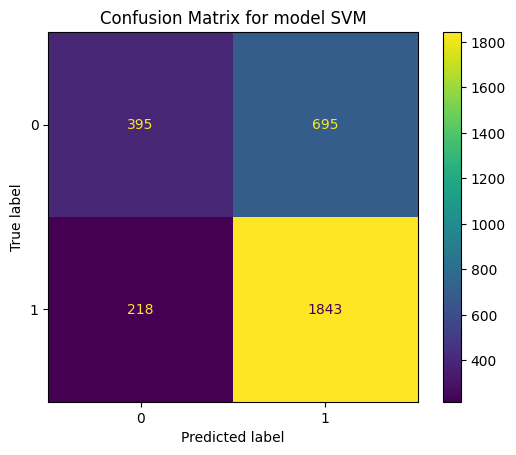

----------------------------------------------------


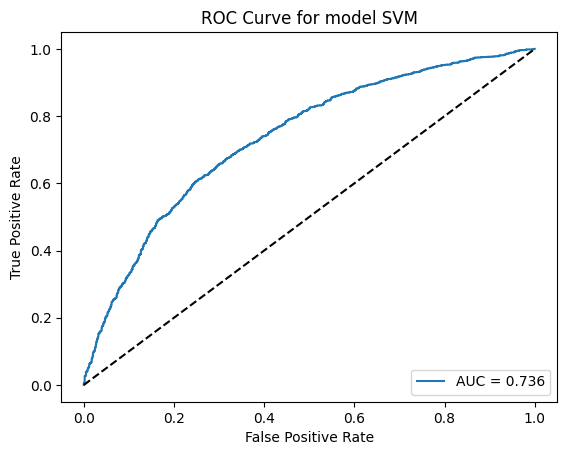

Accuracy: 0.7102507140590288
Precision: 0.7261623325453113
F1-Score: 0.8014785823005001
AUC: 0.7355545762500612


In [8]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'SVM')
result.loc[0] = ['SVM', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

In [9]:
print(f'O tamanho original teste é: {len(y_test)}')
print(f'O tamanho após o teste é: {len(y_pred)}')
print(f'\nO tamanho da amostra de treino é: {len(X_train_scaled)}')

O tamanho original teste é: 3151
O tamanho após o teste é: 3151

O tamanho da amostra de treino é: 12601


#### SVM com otimização de hiperparâmetros

Em seguida, utilizou-se RandomizedSearchCV por se utilizar de um modelo mais custoso. Dessa forma, espera-se que a classficação seja otimizada, pois ela foi utilizado dentro de um leque de parâmetros oferecidos pela documentação do projeto.

(Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


In [10]:
from sklearn.svm import SVC
from scipy.stats import loguniform

# --- Pipeline com normalização e SVM ---
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42, cache_size=1000, max_iter=10000))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'svc' é o nome do passo do SVC dentro do pipeline

# 2. Espaço de Busca (prefixo 'svc__' para parâmetros do SVC dentro do pipeline)
param_dist = {
    'svc__C':      loguniform(1e-2, 1e2),           # potência: [0.01, 100]
    'svc__kernel': ['rbf', 'linear', 'poly'],
    'svc__gamma':  ['scale', 'auto'],               # ignorado pelo kernel linear
    'svc__degree': [2, 3, 4, 5],                    # só usado pelo kernel poly
}

# 3. Busca do melhor modelo
search_svm = RandomizedSearchCV(
    estimator           = pipe_svm,
    param_distributions = param_dist,
    n_iter              = 40,     # Número de combinações testadas
    cv                  = 5,      # Número de folds usados no Cross-Validation
    scoring             = ['accuracy','roc_auc'],
    refit               = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o scaler internamente)
search_svm.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_svm = search_svm.best_estimator_
print("Melhores hiperparâmetros (com prefixo do pipeline):", search_svm.best_params_)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará scaler)
y_pred = best_svm.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_svm.decision_function(X_test)

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_svm.pkl'
dump(best_svm, nome)
print(f"\nModelo salvo em '{nome}'")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\cauab\OneDrive\Área de Trabalho\TCC\venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Melhores hiperparâmetros (com prefixo do pipeline): {'svc__C': np.float64(2.2233337605920376), 'svc__degree': 2, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}

Modelo salvo em 'models_V2/modelo_svm.pkl'


Classification Report for model SVM otimizado:

               precision    recall  f1-score   support

           0       0.63      0.42      0.51      1090
           1       0.74      0.87      0.80      2061

    accuracy                           0.71      3151
   macro avg       0.69      0.65      0.65      3151
weighted avg       0.70      0.71      0.70      3151



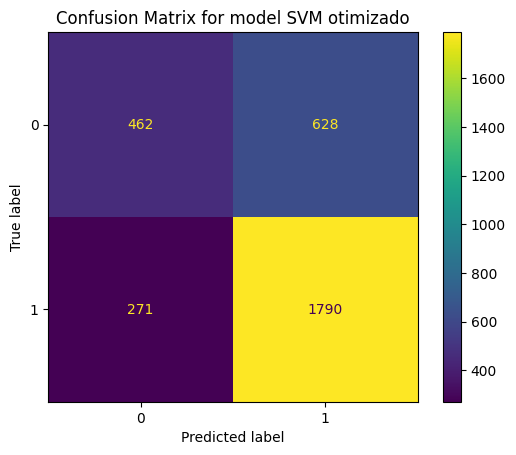

----------------------------------------------------


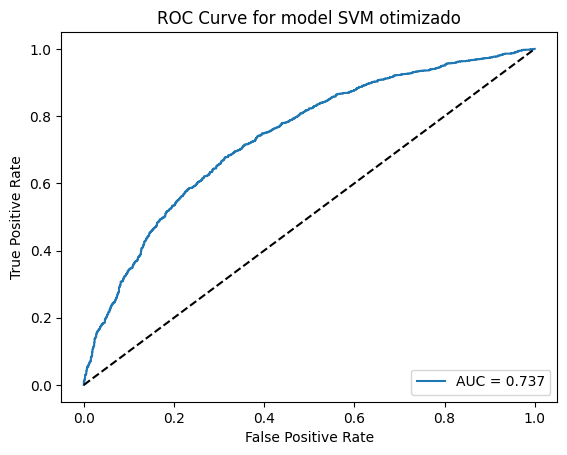

Accuracy: 0.7146937480165027
Precision: 0.7402812241521919
F1-Score: 0.7992855548113418
AUC: 0.7374508677982097


In [11]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'SVM otimizado')
result.loc[1] = ['SVM (otimizado)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### 3.2 Decision Trees (Árvores de Decisão)

Assim como no método KNN, a árvore de decisão foi escolhido para esta tarefa com fins de comparação ao artigo base, bem como à sua simplicidade e interpretabilidade. As árvores de decisão são amplamente utilizadas em problemas de aprendizado supervisionado, pois oferecem uma forma clara de visualizar o processo de tomada de decisão do modelo. Elas funcionam dividindo recursivamente o espaço de características em regiões que maximizam a separação das classes (tendo em vista os métodos de avaliação de divisão), criando um modelo fácil de interpretar que pode lidar tanto com variáveis categóricas quanto contínuas.

Os dois métodos para avaliação de divisão das classes são:

* Gini: Mede a impureza de um nó. Um nó é puro se todas as amostras pertencem à mesma classe.
* Entropia (ou ganho de informação): Mede a quantidade de desordem ou imprevisibilidade em um nó

In [12]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# --- Pipeline com normalização e DT ---
pipe_DT = Pipeline([
    ('scaler', MinMaxScaler()),   # opcional para DecisionTree
    ('dt', DecisionTreeClassifier(random_state=42))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'dt' é o nome do passo da DT dentro do pipeline

# 2. Espaço de Busca (prefixo 'dt__' para parâmetros do DT dentro do pipeline)
#    Observação: GridSearch testa todas as combinações; mantenha o grid razoável para evitar explosão combinatória.
hyperparameters_DT = {
    'dt__max_depth': [None] + list(range(1, 10)),        # None ou profundidades de 1 a 10
    'dt__min_samples_split': [2, 5, 10],                 # valores típicos
    'dt__min_samples_leaf': [1, 2, 4],                   # valores típicos
    'dt__criterion': ['gini', 'entropy']
}

# 3. Busca do melhor modelo
DTree_classifier = GridSearchCV(estimator=pipe_DT,
                                param_grid   = hyperparameters_DT,
                                cv           = 5,      # Número de folds usados no Cross-Validation
                                scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc'},
                                refit        = 'roc_auc',
                                n_jobs       = -1,
                                verbose      = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o pré-processamento se houver)
DTree_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = DTree_classifier.best_estimator_
best_params = DTree_classifier.best_params_

print("Melhores parâmetros:", best_params)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará qualquer pré-processamento)
y_pred = best_estimator.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_estimator.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_DT.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Melhores parâmetros: {'dt__criterion': 'entropy', 'dt__max_depth': 6, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 2}

Modelo salvo em 'models_V2/modelo_DT.pkl'


Classification Report for model DT (otimizada):

               precision    recall  f1-score   support

           0       0.61      0.21      0.31      1090
           1       0.69      0.93      0.79      2061

    accuracy                           0.68      3151
   macro avg       0.65      0.57      0.55      3151
weighted avg       0.66      0.68      0.63      3151



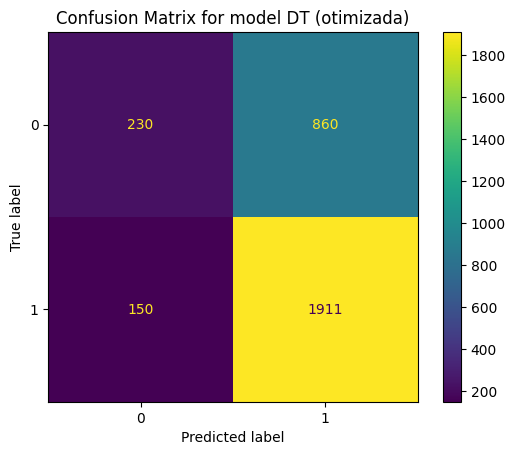

----------------------------------------------------


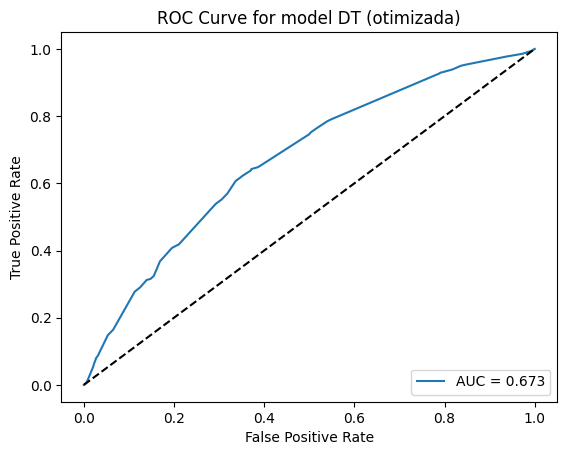

Accuracy: 0.6794668359251032
Precision: 0.689642728256947
F1-Score: 0.7909768211920529
AUC: 0.6725507347016902


In [13]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'DT (otimizada)')
result.loc[2] = ['DT (otimizada)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### 3.3 Random Forests

O modelo Random Forest também foi selecionado para uso. Seguindo o uso de algoritmos que utilizam árvores de decisão, o RandomForestClassifier do scikit-learn baseia-se em árvores independentes treinadas em amostras aleatórias, capturando diferentes aspectos dos dados e reduzindo os efeitos de variância através do processo de agregação. Devido à tal natureza do método, ele é menos suscetível a overfitting em comparação com uma única árvore de decisão.

Fora isso, outro motivo que levou à escolha de seu uso foram pela possibilidade de capturar relações não lineares nos dados, tornando-a adequada para o caso das relações entre variáveis não serem simplesmente lineares e não estar claro quais são os atributos mais relevantes. Por fim, as random forest também são consideradas escolhas sólidas para conjuntos de dados de tamanho moderado, como é o caso.

Para encontrar as melhores combinações de hiperparâmetros, foi novamente utilizado o RandomizedSearchCV, explicado previamente.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# --- Pipeline com normalização e RF ---
pipe_RF = Pipeline([
    ('scaler', MinMaxScaler()),   # opcional para DecisionTree
    ('rf', RandomForestClassifier(random_state=42))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'rf' é o nome do passo da Random Forest dentro do pipeline

# 2. Espaço de Busca (prefixo 'rf__' para parâmetros do DT dentro do pipeline)
#    Observação: GridSearch testa todas as combinações
hyperparameters_RF = {
    'rf__max_depth': [None] + list(range(10,100,10)),    
    'rf__min_samples_split': [2, 5, 10],                 # valores típicos
    'rf__min_samples_leaf': [1, 2, 4],                   # valores típicos
    'rf__criterion': ['gini', 'entropy'],
    'rf__bootstrap':  [True,False],
    'rf__max_features': ['auto','sqrt']
}

# 3. Busca do melhor modelo
RF_classifier = GridSearchCV(estimator   = pipe_RF,
                            param_grid   = hyperparameters_RF,
                            cv           = 5,      # Número de folds usados no Cross-Validation
                            scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc'},
                            refit        = 'roc_auc',
                            n_jobs       = -1,
                            verbose      = 0
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o pré-processamento se houver)
RF_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = RF_classifier.best_estimator_
best_params = RF_classifier.best_params_

print("Melhores parâmetros:", best_params)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará qualquer pré-processamento)
y_pred = best_estimator.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_estimator.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_RF.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

c:\Users\cauab\OneDrive\Área de Trabalho\TCC\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1800 fits failed out of a total of 3600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1109 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\cauab\OneDrive\Área de Trabalho\TCC\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\cauab\OneDrive\Área de Trabalho\TCC\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\cauab\OneDrive\Área d

Melhores parâmetros: {'rf__bootstrap': False, 'rf__criterion': 'entropy', 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2}

Modelo salvo em 'models_V2/modelo_RF.pkl'


Classification Report for model RF (otimizada):

               precision    recall  f1-score   support

           0       0.68      0.41      0.51      1090
           1       0.74      0.90      0.81      2061

    accuracy                           0.73      3151
   macro avg       0.71      0.65      0.66      3151
weighted avg       0.72      0.73      0.71      3151



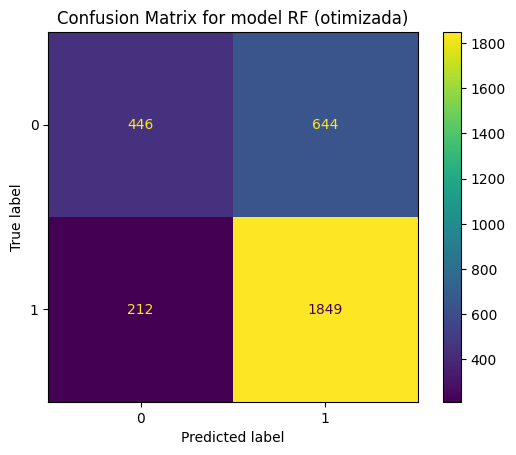

----------------------------------------------------


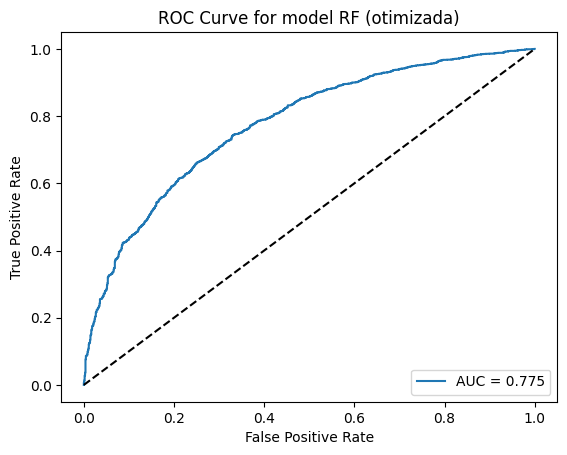

Accuracy: 0.7283402094573151
Precision: 0.7416766947452869
F1-Score: 0.8120333772507685
AUC: 0.7752320286313316


In [15]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'RF (otimizada)')
result.loc[3] = ['RF (otimizada)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### 3.4. XGBoost (Extreme Gradient Boosting)

O modelo xgboost foi escolhido para ser usado uma vez que é sabido de seu potencial em problemas de aprendizado supervisionado como classificação, em que seu desempenho se mostra melhor que outros modelos em muitos casos. Isso se deve ao boosting do modelo, que consiste na combinação de diversos modelos preditivos "fracos", sendo esses árvores de decisão, para construção de um modelo único preditivo forte.

Na aplicação demonstrada abaixo, conforme consulta das respectivas documentações do sklearn e do xgboost, usou-se o GridSearchCV para iterar sobre todas combinações possíveis de hiperparâmetros selecionados a partir de uma lista de valores possíveis escolhidos previamente. Para se ter melhor confiabilidade no resultado que determina o melhor modelo dentre as combinações geradas, usou-se cross-validation com 5 folds. O processo descrito é útil para refinar o modelo escolhendo hiperparâmetros que potencializem seu desempenho, ao custo de relativo alto custo computacional para teste de todas combinações possíveis

In [16]:
from xgboost import XGBClassifier

# --- Pipeline com normalização e xgb ---
pipe_xgb = Pipeline([
    ('scaler', MinMaxScaler()),   # opcional para DecisionTree
    ('xgb', XGBClassifier(random_state=42))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'xgb' é o nome do passo da Random Forest dentro do pipeline

# 2. Espaço de Busca (prefixo 'dt__' para parâmetros do DT dentro do pipeline)
hyperparameters_xgb = {
    'xgb__n_estimators': [100, 300],            # Número de Árvores 
    'xgb__max_depth': [3, 5, 7, 9],             # Profundidade Máxima de cada Árvore
    'xgb__learning_rate': [0.01, 0.05, 0.1],    # Taxa de aprendizado
    'xgb__subsample': [0.7, 0.9],               # Fração de amostras usadas por árvore
    'xgb__colsample_bytree': [0.7, 0.9],        # Fração de colunas (features) amostradas por árvore (reduz correlação entre árvores)
    'xgb__min_child_weight': [1, 3, 5],         # peso mínimo de instâncias numa folha; valores altos tornam o modelo mais conservador (menos overfitting)
    # 'xgb__gamma': [0, 0.1, 0.5],                # Penalidade mínima de perda para fazer um split adicional; maior -> mais conservador
    # 'xgb__reg_alpha': [0, 0.01, 0.1],           # Regularização L1 (sparse feature selection)
    # 'xgb__reg_lambda': [1, 1.5, 2.0]            # Regularização L2 (ridge)
}

# 3. Busca do melhor modelo
xgb_classifier = GridSearchCV(estimator  = pipe_xgb,
                            param_grid   = hyperparameters_xgb,
                            cv           = 3,      # Número de folds usados no Cross-Validation
                            scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc'},
                            refit        = 'roc_auc', # após a busca, o melhor modelo será re-treinado com base em 'roc_auc'
                            n_jobs       = -1,
                            verbose      = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o pré-processamento se houver)
xgb_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = xgb_classifier.best_estimator_
best_params = xgb_classifier.best_params_

print("Melhores parâmetros:", best_params)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará qualquer pré-processamento)
y_pred = best_estimator.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_estimator.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_xgboost.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Melhores parâmetros: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 9, 'xgb__min_child_weight': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.7}

Modelo salvo em 'models_V2/modelo_xgboost.pkl'


Classification Report for model XGBoost (otimizado):

               precision    recall  f1-score   support

           0       0.67      0.46      0.54      1090
           1       0.75      0.88      0.81      2061

    accuracy                           0.73      3151
   macro avg       0.71      0.67      0.68      3151
weighted avg       0.72      0.73      0.72      3151



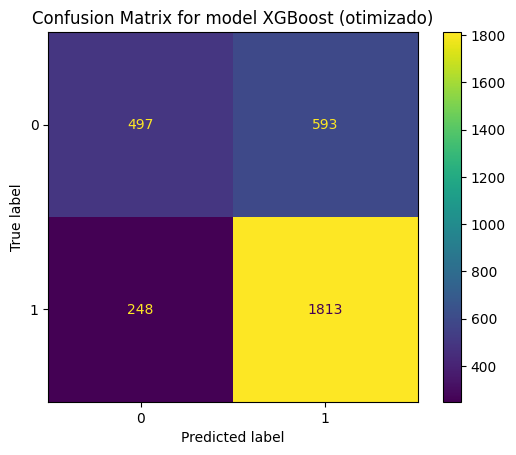

----------------------------------------------------


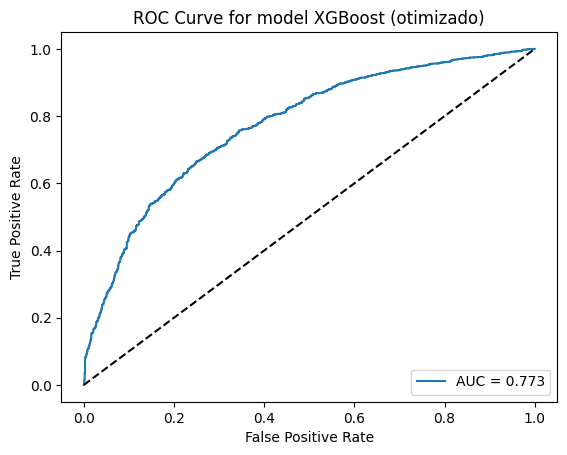

Accuracy: 0.7331006029831799
Precision: 0.7535328345802161
F1-Score: 0.8117304678755317
AUC: 0.7733958308294273


In [17]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'XGBoost (otimizado)')
result.loc[4] = ['XGBoost (otimizado)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### 3.5. k-Nearest Neighbors (KNN)

O KNN também foi utilizado como base de comparação para os demais métodos aplicados, tendo em vista que este se trata de um dos métodos mais simples e intuitivos para tarefas de classificação. 

Esse algortimo utiliza as distâncias entre as amostras: 
1. para uma nova amostra, o algoritmo calcula a distância euclidiana entre a amostra e todos os pontos de dados no conjunto de treinamento; 
2. com base nas distâncias calculadas, seleciona os K pontos de dados mais próximos;
3. A nova amostra é classificada pela maioria dos rótulos dos K vizinhos mais próximos.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# --- Pipeline com normalização e KNN ---
pipe_KNN = Pipeline([
    ('scaler', MinMaxScaler()),   # recomendado para KNN (sensível à escala)
    ('knn', KNeighborsClassifier())
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'knn' é o nome do passo do KNN dentro do pipeline

# 2. Espaço de Busca (prefixo 'knn__' para parâmetros do KNN dentro do pipeline)
#    Observação: GridSearch testa todas as combinações
hyperparameters_KNN = {
    'knn__n_neighbors': list(range(1,20,2)),      # número de vizinhos
    'knn__weights': ['uniform', 'distance'],   # ponderação das distâncias
    'knn__algorithm': ['auto'],
    'knn__leaf_size': [20, 30, 40],            # afeta construção das árvores (kd/ball)
    'knn__p': [1, 2]                           # 1 = Manhattan, 2 = Euclidiana
}

# 3. Busca do melhor modelo
KNN_classifier = GridSearchCV(estimator   = pipe_KNN,
                              param_grid   = hyperparameters_KNN,
                              cv           = 5,      # Número de folds usados no Cross-Validation
                              scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc'},
                              refit        = 'roc_auc',
                              n_jobs       = -1,
                              verbose      = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o pré-processamento se houver)
KNN_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = KNN_classifier.best_estimator_
best_params = KNN_classifier.best_params_

print("Melhores parâmetros:", best_params)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará qualquer pré-processamento)
y_pred = best_estimator.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_estimator.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_knn.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Melhores parâmetros: {'knn__algorithm': 'auto', 'knn__leaf_size': 20, 'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}

Modelo salvo em 'models_V2/modelo_knn.pkl'


Classification Report for model KNN (otimizado):

               precision    recall  f1-score   support

           0       0.59      0.53      0.56      1090
           1       0.76      0.80      0.78      2061

    accuracy                           0.71      3151
   macro avg       0.68      0.67      0.67      3151
weighted avg       0.70      0.71      0.71      3151



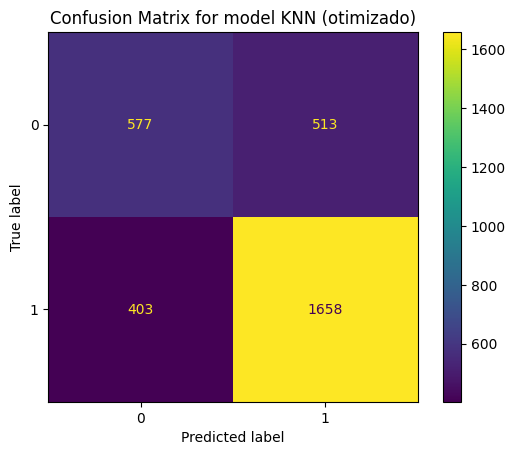

----------------------------------------------------


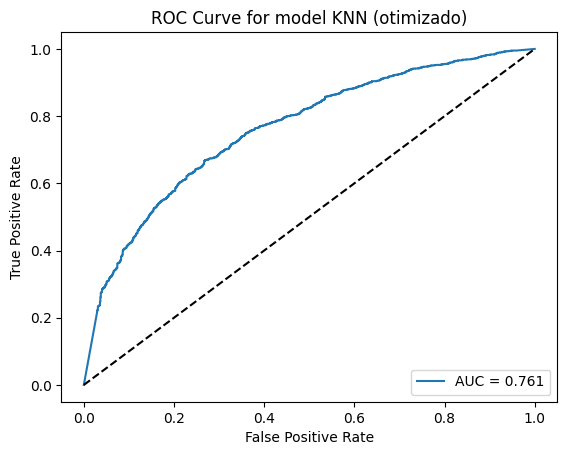

Accuracy : 0.709298635353856
Precision: 0.7637033625057578
F1-Score : 0.7835538752362949
AUC      : 0.7614621031030631


In [19]:
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'KNN (otimizado)')
result.loc[5] = ['KNN (otimizado)', acc, prec, f1_sc, auc_score]
 
print('Accuracy :', acc)
print('Precision:', prec)
print('F1-Score :', f1_sc)
print('AUC      :', auc_score)

### 3.6. Naive Byes

O Naive Bayes também foi utilizado como base de comparação para os demais métodos aplicados, tendo em vista que este se trata de um dos algoritmos mais simples e eficientes computacionalmente para tarefas de classificação, especialmente em problemas envolvendo dados categóricos com grande volume de amostras.

Esse algoritmo utiliza o Teorema de Bayes aliado à suposição de independência entre os atributos:

1. Para uma nova amostra, o algoritmo calcula a probabilidade de cada classe, considerando a frequência dos atributos observados no conjunto de treinamento;
2. Essas probabilidades são obtidas a partir da relação entre a probabilidade a priori da classe e a probabilidade condicional dos atributos dado cada classe;
3. A nova amostra é classificada pela classe que apresenta a maior probabilidade posterior.

No processo de ajuste, o GridSearchCV foi empregado para selecionar os melhores parâmetros do modelo, garantindo maior robustez na comparação com os demais métodos aplicados.

In [20]:
from sklearn.naive_bayes import GaussianNB

# --- Pipeline com normalização e Naive Bayes ---
# Observação: GaussianNB assume distribuição normal dos atributos contínuos.
# O MinMaxScaler garante que todos os atributos estejam na mesma escala,
# o que beneficia a estimação das probabilidades condicionais.
pipe_NB = Pipeline([
    ('scaler', MinMaxScaler()),
    ('nb', GaussianNB())
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'nb' é o nome do passo do Naive Bayes dentro do pipeline

# 2. Espaço de Busca (prefixo 'nb__' para parâmetros do GaussianNB dentro do pipeline)
#    var_smoothing: fração da maior variância das features adicionada a todas as variâncias
#    (suavização gaussiana). Evita divisões por zero e melhora a robustez em atributos
#    com baixa variância. Avaliamos 14 valores em escala logarítmica de 1e-12 a 1e0.
hyperparameters_NB = {
    'nb__var_smoothing': np.logspace(-12, 0, 14)   # 14 valores igualmente espaçados em log
}

# 3. Busca do melhor modelo
NB_classifier = GridSearchCV(
    estimator  = pipe_NB,
    param_grid = hyperparameters_NB,
    cv         = 5,      # Número de folds usados no Cross-Validation
    scoring    = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit      = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o pré-processamento)
NB_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = NB_classifier.best_estimator_
best_params    = NB_classifier.best_params_

print("Melhores parâmetros:", best_params)

# --- Avaliação ---
# Previsões binárias
y_pred   = best_estimator.predict(X_test)
# Probabilidade da classe positiva
y_scores = best_estimator.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_NB.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Melhores parâmetros: {'nb__var_smoothing': np.float64(1e-12)}

Modelo salvo em 'models_V2/modelo_NB.pkl'


Classification Report for model NB (otimizado):

               precision    recall  f1-score   support

           0       0.48      0.51      0.49      1090
           1       0.73      0.70      0.72      2061

    accuracy                           0.64      3151
   macro avg       0.60      0.61      0.61      3151
weighted avg       0.64      0.64      0.64      3151



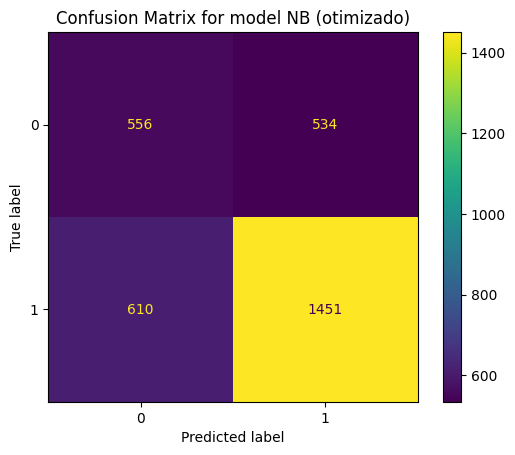

----------------------------------------------------


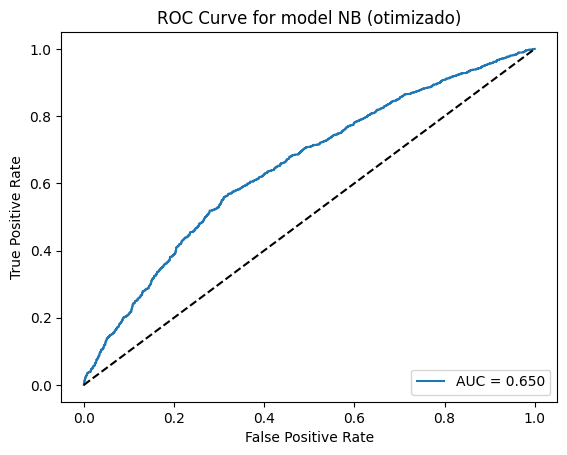

Accuracy : 0.6369406537607109
Precision: 0.7309823677581864
F1-Score : 0.7172516065249629
AUC      : 0.6499094142417727


In [21]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'NB (otimizado)')
result.loc[6] = ['NB (otimizado)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy :', acc)
print('Precision:', prec)
print('F1-Score :', f1_sc)
print('AUC      :', auc_score)

### 3.7. MLP (Multilayer Perceptron)

Por fim, o MLP (Multilayer Perceptron) Classifier foi escolhido, pois ele é um tipo de rede neural artificial composta por várias camadas de neurônios interconectados, que é capaz de aprender relações complexas entre entradas e saídas por meio de treinamento supervisionado. Ele utiliza funções de ativação não lineares, permitindo modelar problemas que não podem ser resolvidos por métodos lineares simples. Dessa forma, deve-se utilizá-lo porque consegue generalizar bem em tarefas diversas e lidar com dados de alta dimensionalidade - o que se encaixa no nosso caso.

Ademais, foi utilizado o RandomizedSearchCV nesse caso, pois o espaço de busca do MLP é muito maior que o dos outros modelos, especialmente por causa de hidden_layer_sizes (cada arquitetura é uma combinação diferente). Além disso, alpha e learning_rate_init são naturalmente contínuos — o RandomizedSearchCV permite amostrá-los com loguniform, o que o GridSearchCV não suporta diretamente. Um Grid exaustivo aqui geraria centenas/milhares de combinações. 

In [22]:
from sklearn.neural_network import MLPClassifier

# 1. Pipeline — MLP é sensível à escala dos dados; StandardScaler é obrigatório
#    para garantir convergência estável do gradiente.
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=500,          # aumentado (300 -> 500) para garantir convergência
                               # em arquiteturas mais profundas
        early_stopping=True,   # interrompe se a validação interna não melhora
        n_iter_no_change=20,   # paciência aumentada (15 -> 20) para sair de platôs
        validation_fraction=0.1
    ))
])

# 2. Espaço de Busca
#
#   hidden_layer_sizes : arquitetura da rede; incluídas redes mais profundas (4 camadas)
#                        e mais largas (até 512 neurônios) em relação à versão anterior.
#   activation         : 'relu' costuma ser mais estável; 'tanh' às vezes supera em
#                        datasets de tamanho médio.
#   alpha              : regularização L2; faixa ampliada (1e-5 a 1e0) para cobrir
#                        cenários de alta e baixa regularização.
#   learning_rate_init : taxa de aprendizado inicial; faixa estendida (1e-4 a 5e-2)
#                        para melhor cobertura de regiões de convergência rápida.
#   learning_rate      : 'adaptive' reduz a taxa automaticamente quando a perda de
#                        treino estagna, acelerando a convergência em fases tardias.
param_dist_mlp = {
    'mlp__hidden_layer_sizes': [
        (64,),
        (128,),
        (256,),
        (64, 32),
        (128, 64),
        (256, 128),
        (512, 256),
        (128, 64, 32),
        (256, 128, 64),
        (512, 256, 128),
        (256, 128, 64, 32),    # arquiteturas de 4 camadas (novas em relação à versão anterior)
        (512, 256, 128, 64),
    ],
    'mlp__activation'         : ['relu', 'tanh'],
    'mlp__alpha'              : loguniform(1e-5, 1e0),    # faixa ampliada (era 1e-4 a 1e-1)
    'mlp__learning_rate_init' : loguniform(1e-4, 5e-2),   # faixa ampliada (era 1e-4 a 1e-2)
    'mlp__learning_rate'      : ['constant', 'adaptive'], # 'adaptive' é novidade
}

# 3. Busca aleatória
search_mlp = RandomizedSearchCV(
    estimator           = pipe_mlp,
    param_distributions = param_dist_mlp,
    n_iter              = 100,    # combinações testadas (era 100)
    cv                  = 5,      # Número de folds usados no Cross-Validation
    scoring             = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit               = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o scaler internamente)
search_mlp.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_mlp    = search_mlp.best_estimator_
best_params = search_mlp.best_params_
print("Melhores hiperparâmetros:", best_params)

# --- Avaliação ---
# Previsões binárias
y_pred   = best_mlp.predict(X_test)
# Probabilidade da classe positiva
y_scores = best_mlp.predict_proba(X_test)[:, 1]

# --- Salvar modelo ---
# Salvar o modelo treinado em um arquivo .pkl
nome = 'models_V2/modelo_MLP.pkl'
dump(best_mlp, nome)   
print(f"\nModelo salvo em '{nome}'")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Melhores hiperparâmetros: {'mlp__activation': 'relu', 'mlp__alpha': np.float64(0.022944454507601995), 'mlp__hidden_layer_sizes': (256, 128, 64, 32), 'mlp__learning_rate': 'adaptive', 'mlp__learning_rate_init': np.float64(0.0004379016717149336)}

Modelo salvo em 'models_V2/modelo_MLP.pkl'


Classification Report for model MLP (otimizado):

               precision    recall  f1-score   support

           0       0.57      0.46      0.51      1090
           1       0.74      0.82      0.78      2061

    accuracy                           0.69      3151
   macro avg       0.66      0.64      0.64      3151
weighted avg       0.68      0.69      0.69      3151



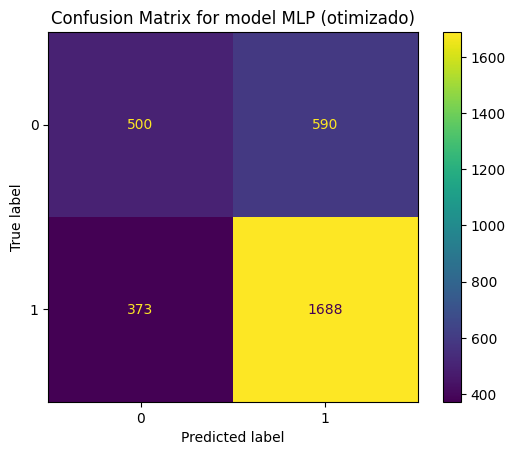

----------------------------------------------------


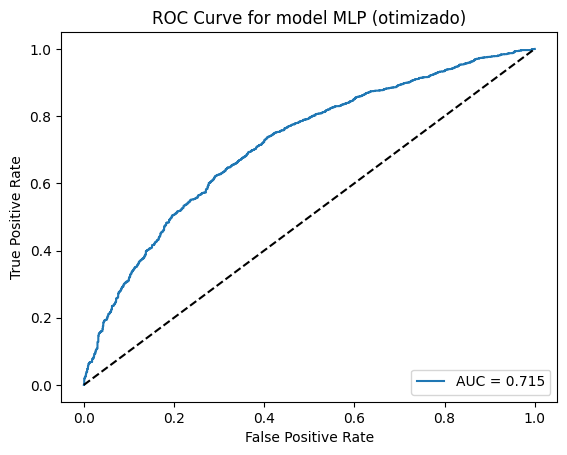

Accuracy : 0.6943827356394795
Precision: 0.7410008779631255
F1-Score : 0.7780594607052316
AUC      : 0.7154552212562708


In [23]:
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'MLP (otimizado)')
result.loc[7] = ['MLP (otimizado)', acc, prec, f1_sc, auc_score]
 
print('Accuracy :', acc)
print('Precision:', prec)
print('F1-Score :', f1_sc)
print('AUC      :', auc_score)

### Comparação das Métricas de Desempenho

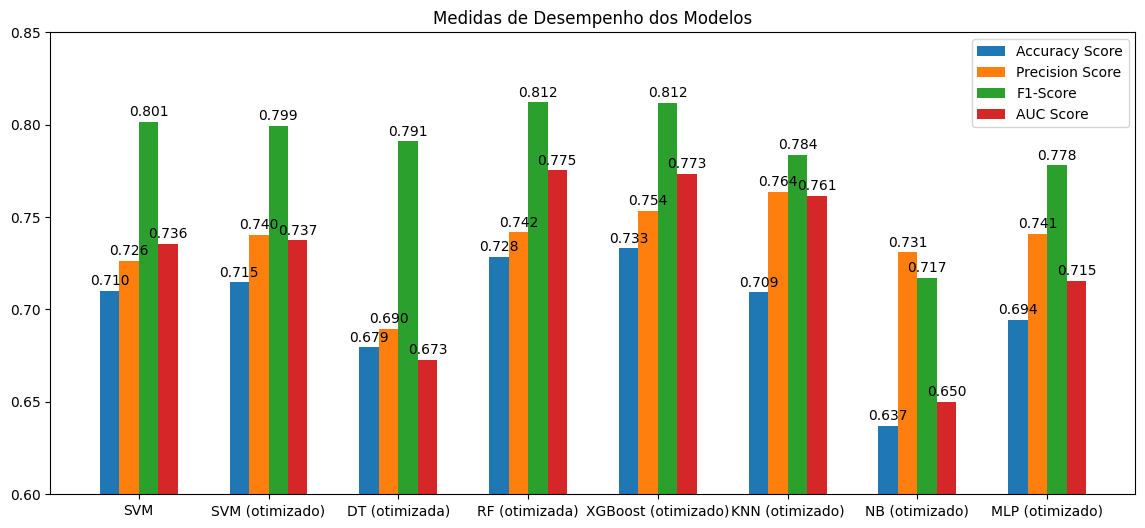

In [24]:
import numpy as np

# Configurações do gráfico
x = np.arange(len(result['Model']))  # posições no eixo x
width = 0.15  # largura das barras

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=(14, 6))

# Plotando as barras
bar1 = ax.bar(x - width, result['Accuracy Score'], width, label='Accuracy Score')
bar2 = ax.bar(x, result['Precision Score'], width, label='Precision Score')
bar3 = ax.bar(x + width, result['F1-Score'], width, label='F1-Score')
bar4 = ax.bar(x + 2*width, result['AUC Score'], width, label='AUC Score')

# Adicionando os valores nas barras
ax.bar_label(bar1, padding=2, fmt='%.3f')
ax.bar_label(bar2, padding=2, fmt='%.3f')
ax.bar_label(bar3, padding=2, fmt='%.3f')
ax.bar_label(bar4, padding=2, fmt='%.3f')

# Configurando o limite do eixo y
ax.set_ylim(0.60, 0.85)

# Adicionando os rótulos e título
ax.set_title('Medidas de Desempenho dos Modelos')
ax.set_xticks(x+width/2)
ax.set_xticklabels(result['Model'])
ax.legend()

# Exibindo o gráfico
plt.show()